In [1]:
#写一个大循环，循环不同的分辨率
# 匹配数目与平均降水
from scipy import stats
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib as mpl
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeat
import matplotlib.pyplot as plt
from cartopy.io.shapereader import Reader
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.feature import ShapelyFeature
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import BoundaryNorm
a=0.2
p = int(7 / a)
q = int(11 / a)

c:\ProgramData\miniconda3\envs\pystudy\Lib\site-packages\pyproj\__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
gauge_pre_grided=np.load('gauge_pre_grided.npy')
satellite_pre=np.load("precip_all_hour_satellite.npy")

In [3]:
gauge_pre_num=np.load("gauge_pre_num.npy")

In [4]:
gauge_pre_num.shape

(43848, 35, 55)

In [5]:
#添加误差
def func(x, a, b):
    return a * np.exp(-b * x)

def get_ab_values(rain):
    if rain < 2:
        return 0.45131016517318423, 0.16169399717438698
    elif 2 <= rain < 4:
        return  1.6794847980908945, 0.16198899816352366
    elif 4 <= rain < 8:
        return 3.437138732494024, 0.16260406256981108
    elif rain >= 8:
        return 7.550905959233764, 0.16581205841013613
    else:
        return -9999,-9999


In [6]:
gauge_pre_num.shape

(43848, 35, 55)

In [7]:
# 定义每年的小时数（已知两个闰年）
hours_per_year = [8784, 8760, 8760, 8760, 8784]

# 预计算各季节起始索引（基于每年1月1日0时为起点）
season_slices = [
    # 春季：3-5月（按闰年计算，实际使用时根据年份索引选择）
    {"start": 31*24 + 28*24, "end": 31*24 + 28*24 + 92*24},  # 3/1 0:00 ~ 5/31 23:00
    
    # 夏季：6-8月
    {"start": 31*24 + 28*24 + 92*24, "end": 31*24 + 28*24 + 92*24 + 92*24},
    
    # 秋季：9-11月
    {"start": 31*24 + 28*24 + 184*24, "end": 31*24 + 28*24 + 184*24 + 91*24},
    
    # 冬季：当年12月 + 次年1-2月（修正为仅当前年）
    {"start": 334*24, "end": 365*24},  # 12/1 0:00 ~ 12/31 23:00
    {"pre_start": 0, "pre_end": 59*24}  # 1/1 0:00 ~ 2/28 23:00
]

# 动态生成各年实际索引（考虑闰年）
def get_season_indices(year_idx, is_leap):
    base = sum(hours_per_year[:year_idx])
    leap_offset = 24 if is_leap else 0
    
    return {
        "spring": (
            base + (31*24 + 28*24 + leap_offset),  # 3/1 0:00
            base + (31*24 + 28*24 + 92*24 + leap_offset)
        ),
        "summer": (
            base + (31*24 + 28*24 + 92*24 + leap_offset),
            base + (31*24 + 28*24 + 184*24 + leap_offset)
        ),
        "autumn": (
            base + (31*24 + 28*24 + 184*24 + leap_offset),
            base + (31*24 + 28*24 + 275*24 + leap_offset)
        ),
        "winter": [
            (base + 334*24, base + (366 if is_leap else 365)*24),  # 12/1 ~ 年底
            (base, base + 59*24 + (24 if is_leap else 0))          # 1/1 ~ 2/29/28
        ]
    }


# 初始化季节数据容器
pre = [[] for _ in range(4)]
pre_up = [[] for _ in range(4)]
num = [[] for _ in range(4)]

# 处理每个年份的数据
cursor = 0
for year in range(5):
    is_leap = (hours_per_year[year] == 8784)
    indices = get_season_indices(year, is_leap)
    
    # 切割四季数据
    for i, season in enumerate(["spring", "summer", "autumn"]):
        start, end = indices[season]
        pre[i].append(gauge_pre_grided[start:end])
        pre_up[i].append(satellite_pre[start:end])
        num[i].append(gauge_pre_num[start:end])
    
    # 冬季特殊处理：12月 + 1-2月（同一年内）
    winter12 = gauge_pre_grided[indices["winter"][0][0]:indices["winter"][0][1]]
    winter1_2 = gauge_pre_grided[indices["winter"][1][0]:indices["winter"][1][1]]
    pre[3].append(np.concatenate([winter1_2, winter12]))
    
    sate_winter12 = satellite_pre[indices["winter"][0][0]:indices["winter"][0][1]]
    sate_winter1_2 = satellite_pre[indices["winter"][1][0]:indices["winter"][1][1]]
    pre_up[3].append(np.concatenate([sate_winter1_2, sate_winter12]))

    sate_winter12 = gauge_pre_num[indices["winter"][0][0]:indices["winter"][0][1]]
    sate_winter1_2 = gauge_pre_num[indices["winter"][1][0]:indices["winter"][1][1]]
    num[3].append(np.concatenate([sate_winter1_2, sate_winter12]))

In [8]:
#把五维list，转为四维，把年份的维度合并
pre_4d={}
pre_up_4d={}
num_4d={}
for i in range(4):
    pre_4d[i]=[]
    pre_up_4d[i]=[]
    num_4d[i]=[]
    for j in range(5):
        pre_4d[i].append(pre[i][j])
        pre_up_4d[i].append(pre_up[i][j])
        num_4d[i].append(num[i][j])
    pre_4d[i]=np.concatenate(pre_4d[i], axis=0)
    pre_up_4d[i]=np.concatenate(pre_up_4d[i], axis=0)
    num_4d[i]=np.concatenate(num_4d[i], axis=0)

In [9]:
pre[i][j].shape

(2208, 35, 55)

In [10]:
pre_4d[3].shape

(10896, 35, 55)

In [ ]:
wucha={}

for s in range(4):#四个季节
    print(s)
    wucha[s]=np.full(pre_4d[s].shape,np.nan)
    wucha[s+4]=np.full(pre_4d[s].shape,np.nan)
    for t in range(len(pre_4d[s])):
        pre_4d[s][(pre_4d[s]<0.1) & (pre_up_4d[s]<0.1)]=np.nan
        pre_up_4d[s][(pre_4d[s]<0.1) & (pre_up_4d[s]<0.1)]=np.nan
        for i in range(35):
            for j in range(55):
                # if pre[s][t,i,j]<0.1 and pre_up[s][t,i,j]<0.1:
                #     continue
                if pre_4d[s][t,i,j]!=pre_4d[s][t,i,j] or pre_up_4d[s][t,i,j]!=pre_up_4d[s][t,i,j]:
                    continue
                a,b=get_ab_values(pre_4d[s][t,i,j])
                if a<-999 or b<-999:
                    print(s,t,i,j,a,b,num_4d[s][t,i,j],pre_4d[s][t,i,j])
                wucha[s][t,i,j]=(np.abs(pre_up_4d[s][t,i,j]-pre_4d[s][t,i,j]) +func(num_4d[s][t,i,j],a,b))**2
                # print(t,i,j,pre[s][t,i,j],pre_up[s][t,i,j],a,b)
                wucha[s+4][t,i,j]=(np.max([0.,np.abs(pre_up_4d[s][t,i,j]-pre_4d[s][t,i,j])-func(num_4d[s][t,i,j],a,b,)]))**2


In [ ]:
# np.save('wucha_huatu8.npy',wucha)

In [12]:
wucha=np.load('wucha_huatu8.npy',allow_pickle=True).item()

In [13]:
huatus={}
for i in range(8):
    huatus[i]=np.sqrt(np.nanmean(wucha[i],axis=0))
print(np.nanmean(huatus[0]),np.nanmean(huatus[1]),np.nanmean(huatus[2]),np.nanmean(huatus[3]))
print(np.nanmean(huatus[4]),np.nanmean(huatus[5]),np.nanmean(huatus[6]),np.nanmean(huatus[7]))

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17392\3320384290.py:3: RuntimeWarning: Mean of empty slice
  huatus[i]=np.sqrt(np.nanmean(wucha[i],axis=0))


2.0589636304377237 4.063727263096877 2.299212882066795 1.4669548334190066
1.3238371085030916 2.7683020676598016 1.477590890197127 1.0987061107043326


In [14]:
plt.rcParams["font.sans-serif"] = ["Arial"]  # 用于显示中文,Arial
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False  # 用于显示中文

# --设置shp路径，数据集已公开
shp_path = r"E:\0000000000\map_data\bou2_4p.dbf"
# --设置tif路径，数据集已公开
tif_path = r"E:\0000000000\map_data\地形数据\NE1_50M_SR_W.tif"

bins = np.arange(0,6.02,0.02)#,np.arange(2,2.5,0.01))
#bins = np.arange(0,0.2,0.01)
nbin = len(bins) + 1
cmap1 =plt.get_cmap("Spectral_r", nbin)
norm1 = mpl.colors.BoundaryNorm(bins, nbin,extend='both')

# bins = np.logspace(0, np.log10(50), num=100)  # 使用对数刻度范围
# nbin = len(bins)
# cmap1 = plt.get_cmap("rainbow", nbin)

# # 使用 LogNorm 进行颜色归一化
# norm1 = mpl.colors.LogNorm(vmin=1e-1, vmax=50)  # 对数归一化，确保数据范围有效

bins = np.arange(0,6.02,0.02)
#bins = np.arange(0,0.2,0.01)
nbin = len(bins) + 1
cmap2 = plt.get_cmap("Spectral_r", nbin)
norm2 = mpl.colors.BoundaryNorm(bins, nbin,extend='both')

In [15]:
print(np.nanstd(huatus[0])/np.nanmean(huatus[0]),np.nanstd(huatus[1])/np.nanmean(huatus[1]),np.nanstd(huatus[2])/np.nanmean(huatus[2]),np.nanstd(huatus[3])/np.nanmean(huatus[3]))
print(np.nanstd(huatus[4])/np.nanmean(huatus[4]),np.nanstd(huatus[5])/np.nanmean(huatus[5]),np.nanstd(huatus[6])/np.nanmean(huatus[6]),np.nanstd(huatus[7])/np.nanmean(huatus[7]))

0.23163631281942929 0.1911813202040425 0.27349860417562416 0.5791126643795184
0.22700463522891495 0.17547028555933855 0.3270907587250395 0.7493736391138072


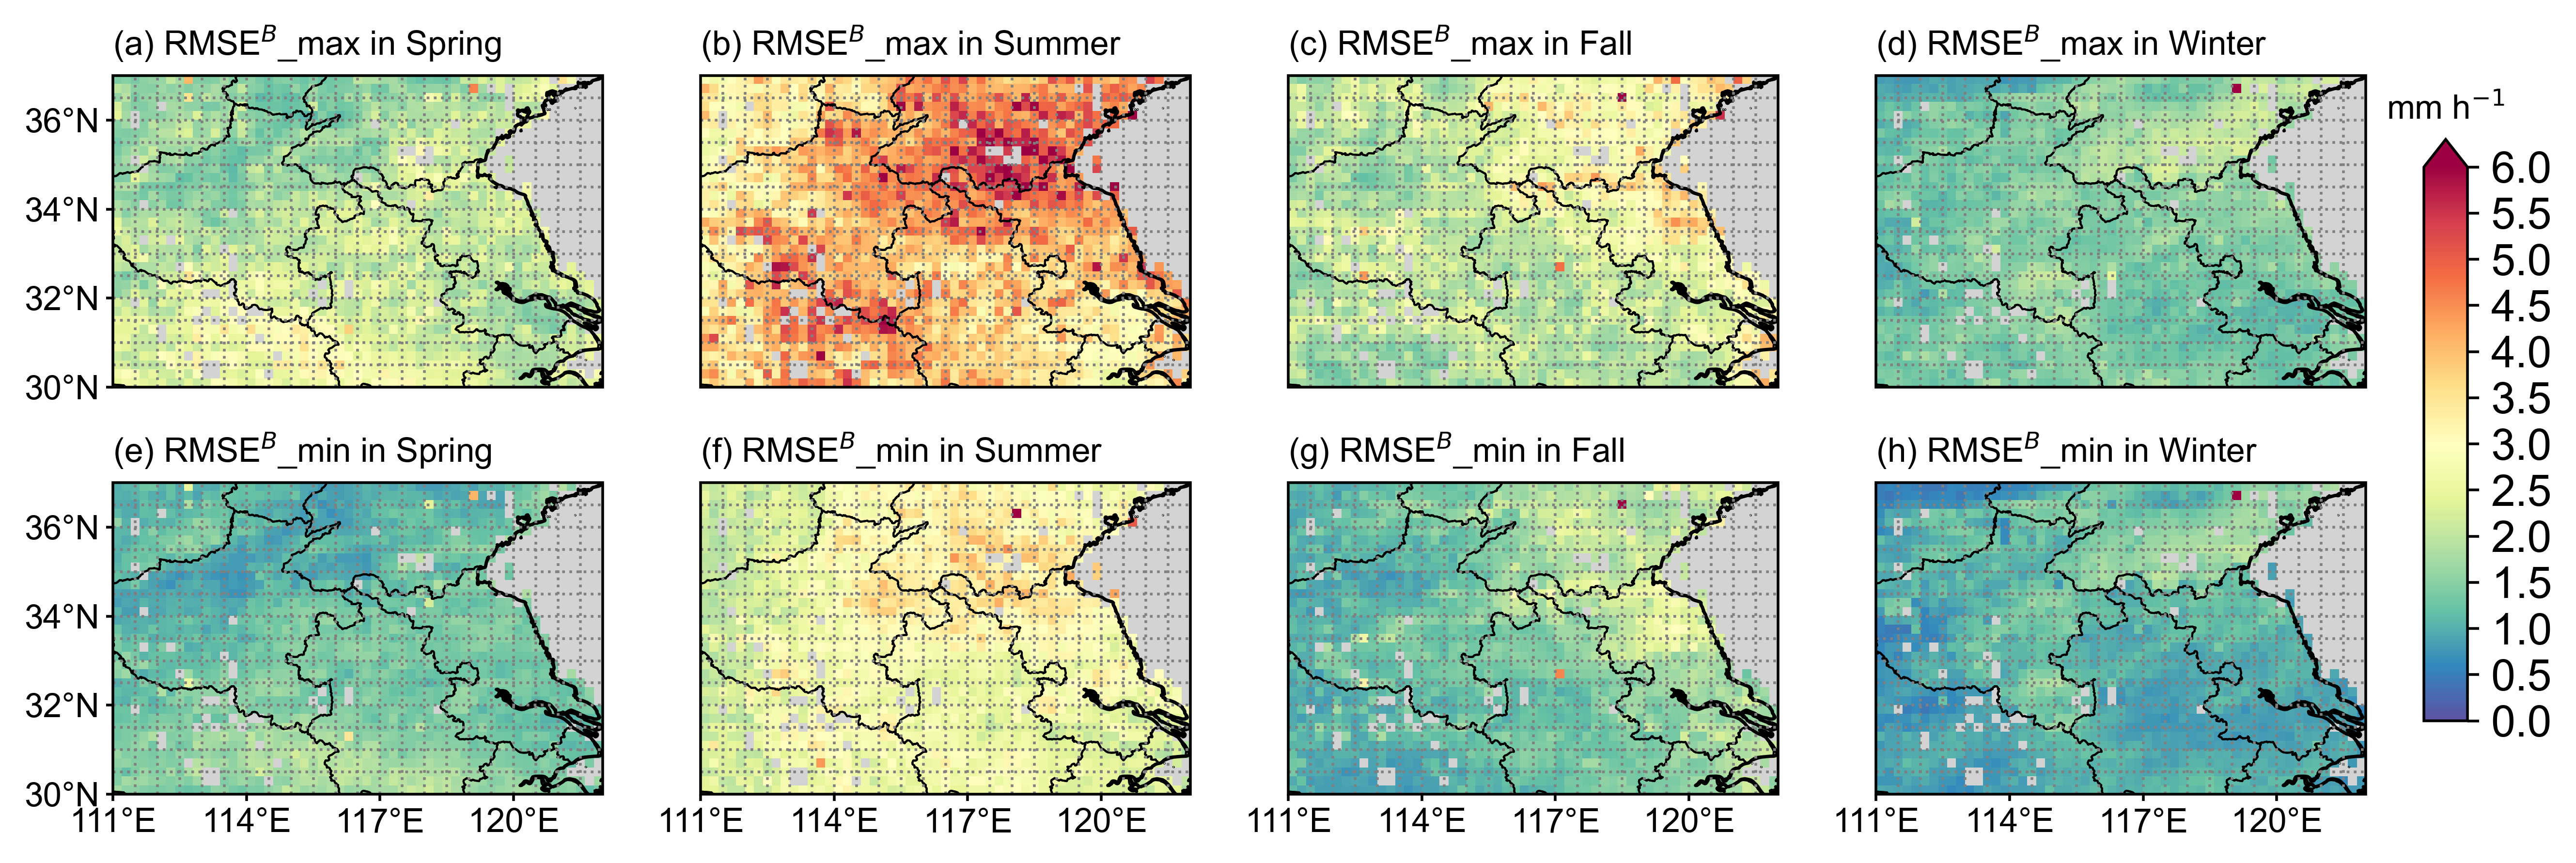

In [16]:

fig, axs = plt.subplots(2, 4, figsize=(12, 4), dpi=500,subplot_kw={'projection': ccrs.PlateCarree()}#,gridspec_kw={'hspace': 0.05 }#'wspace': 0.0,
                        )
axs=axs.ravel()
for i in range(8):
    ax = axs[i]
    ax.coastlines()
    
    ax.patch.set_facecolor("lightgrey") 
    provinces = ShapelyFeature(Reader(shp_path).geometries(), ccrs.PlateCarree(), edgecolor="k", facecolor="none")
    ax.add_feature(provinces, lw=0.6, zorder=2)
    
    ax.set_extent([111, 122, 30, 37], crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.8, color="gray", linestyle=":")
    gl.top_labels, gl.bottom_labels, gl.right_labels, gl.left_labels = False, False, False, False
    gl.xlocator = mticker.FixedLocator(np.arange(111, 122, 0.5))
    gl.ylocator = mticker.FixedLocator(np.arange(30, 37, 0.5))
    
    if i==0 or i==4  :
        ax.set_yticks(np.arange(30, 38, 2), crs=ccrs.PlateCarree())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelcolor="k", length=2, labelsize=10,rotation=0,pad=2)

    if i in [4,5,6,7]  :
    # if i in [0,1,2,3]  :
        ax.set_xticks(np.arange(111, 123, 3), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.tick_params(labelcolor="k", length=2, labelsize=10,rotation=0,pad=2)

    if i in [0,1,2,3]:
        im = ax.imshow(huatus[i],#alpha=colors[i,j],
            cmap=cmap1,
            norm=norm1,
            origin="lower",
            extent=(111, 122, 30, 37),
        )
    if i in [4,5,6,7]:
        im = ax.imshow(huatus[i],#alpha=colors[i,j],
            cmap=cmap2,
            norm=norm2,
            origin="lower",
            extent=(111, 122, 30, 37),
        )
    if i==3:
        cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
        cbar=plt.colorbar (im,cax=cbar_ax,extend='max',orientation='vertical',ticks=np.arange(0,6.5,0.5))
        font = {#'family' : 'serif',
                        #'color'  : 'darkred',
                        #'weight' : 'normal',
                        'size'   : 10,}
        cbar.ax.set_title('mm h$^{-1}$',fontdict=font)
        cbar.ax.tick_params(labelsize=13)
        cbar.minorticks_off()

    # if i==7:
    #     cbar_ax = fig.add_axes([0.91, 0.13, 0.015, 0.3])
    #     cbar=plt.colorbar (im,cax=cbar_ax,extend='max',orientation='vertical',ticks=np.arange(0,5,0.5))
    #     font = {#'family' : 'serif',
    #                     #'color'  : 'darkred',
    #                     #'weight' : 'normal',
    #                     'size'   : 10,}
    #     cbar.ax.set_title('mm/h',fontdict=font)
    #     cbar.ax.tick_params(labelsize=13)
    #     cbar.minorticks_off()


#plt.tight_layout()
axs[0].set_title('(a) RMSE$^B$_max in Spring',fontsize=10,loc='left')
axs[1].set_title('(b) RMSE$^B$_max in Summer',fontsize=10,loc='left')
axs[2].set_title('(c) RMSE$^B$_max in Fall',fontsize=10,loc='left')
axs[3].set_title('(d) RMSE$^B$_max in Winter',fontsize=10,loc='left')
axs[4].set_title('(e) RMSE$^B$_min in Spring',fontsize=10,loc='left')
axs[5].set_title('(f) RMSE$^B$_min in Summer',fontsize=10,loc='left')
axs[6].set_title('(g) RMSE$^B$_min in Fall',fontsize=10,loc='left')
axs[7].set_title('(h) RMSE$^B$_min in Winter',fontsize=10,loc='left')

# axs[0].annotate('(a)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)
# axs[1].annotate('(b)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)
# axs[2].annotate('(c)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)
# axs[3].annotate('(d)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)
# axs[4].annotate('(e)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)
# axs[5].annotate('(f)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)
# axs[6].annotate('(g)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)
# axs[7].annotate('(h)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)

# axs[0].set_ylabel('RMSE$^B$_max',fontsize=12)
# axs[4].set_ylabel('RMSE$^B$_min',fontsize=12)

plt.show()